In [1]:
import yt
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy
from importlib.resources import files
from IPython.display import Image
from scipy.spatial.transform import Rotation as R
import imageio.v2 as imageio
import os
import math
from constants import SIMULATION_PATH

In [2]:
epf = [
    ("particle_family", "b"),
    ("particle_tag", "b"),
    ("particle_birth_epoch", "d"),
    ("particle_metallicity", "d"),
]

ds = yt.load(SIMULATION_PATH, extra_particle_fields=epf)
ad = ds.all_data() 

yt : [INFO     ] 2026-05-02 14:28:09,877 Parameters: current_time              = 0.3604448649237178 Gyr
yt : [INFO     ] 2026-05-02 14:28:09,879 Parameters: domain_dimensions         = [64 64 64]
yt : [INFO     ] 2026-05-02 14:28:09,880 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2026-05-02 14:28:09,881 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2026-05-02 14:28:09,882 Parameters: cosmological_simulation   = True
yt : [INFO     ] 2026-05-02 14:28:09,884 Parameters: current_redshift          = 12.171087046255657
yt : [INFO     ] 2026-05-02 14:28:09,885 Parameters: omega_lambda              = 0.685000002384186
yt : [INFO     ] 2026-05-02 14:28:09,886 Parameters: omega_matter              = 0.314999997615814
yt : [INFO     ] 2026-05-02 14:28:09,888 Parameters: omega_radiation           = 0.0
yt : [INFO     ] 2026-05-02 14:28:09,889 Parameters: hubble_constant           = 0.674000015258789
yt : [WARNING  ] 2026-05-02 14:28:10,159 This output

In [3]:
x1 = ad["star", "particle_position_x"].in_units("pc")
y1 = ad["star", "particle_position_y"].in_units("pc")
z1 = ad["star", "particle_position_z"].in_units("pc")

center_pc = (np.mean(x1), np.mean(y1), np.mean(z1))

#convert center_pc to astropy.skycoord
from astropy.coordinates import SkyCoord
from astropy import units as u

coord = SkyCoord(x=np.mean(x1) * u.pc,
                y=np.mean(y1) * u.pc,
                z=np.mean(z1) * u.pc,
                 frame='galactocentric')
coord_icrs = coord.transform_to('icrs')
x2 = x1 - center_pc[0]
y2 = y1 - center_pc[1]
z2 = z1 - center_pc[2]

xyz2 = np.array([(x2[i], y2[i], z2[i]) for i in range(len(x2))])

yt : [INFO     ] 2026-05-02 14:28:11,133 Identified   384/  384 intersecting domains (  385 through hilbert key indexing)


In [4]:
dist = np.sqrt(x2**2 + y2**2 + z2**2)

#get index of the particle with the maximum distance
max_index = np.argmax(dist)
dist[max_index]

unyt_quantity(4827.51382227, 'pc')

In [5]:
from silmaril import Galaxy

[4.28478793e-10 4.31015108e-10 4.31015108e-10 ... 3.23923959e-10
 3.23940333e-10 3.39084053e-10]


C:\Users\kevin\AppData\Local\Temp\ipykernel_6192\2515749674.py:4: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


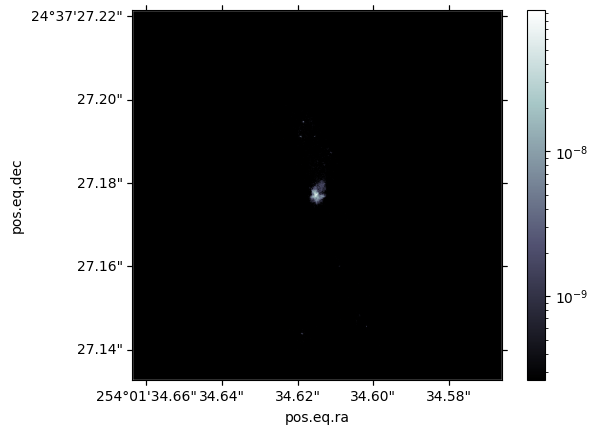

In [6]:
g = Galaxy("output.txt", coord_icrs, ds.current_redshift, dist[max_index].value/30)

fig, ax = g.plot(800)
fig.show()